# **01. Problem Statement**

> ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure for new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.

> Estimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.

> We have a csv file with data of 1300 customers and we are not going too far behind bcs medical charges can have changed due to inflation and other reasons.

In [2]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [3]:
from urllib.request import urlretrieve

In [4]:
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x1c6e28b8e10>)

In [5]:
import pandas as pd

In [6]:
medical_df = pd.read_csv('medical.csv')
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
medical_df.shape

(1338, 7)

> The dataset contains 1338 rows and 7 columns. Each row of the dataset contains information about one customer.

> Our objective is to find a way to estimate the value in the "charges" column using the values in the other columns. If we can do so for the historical data, then we should able to estimate charges for new customers too, simply by asking for information like their age, sex, BMI, no. of children, smoking habits and region.

In [8]:
# medical_df.dtypes
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


> The ranges of values in the numerical columns seem reasonable too (no negative ages!), so we may not have to do much data cleaning or correction. The "charges" column seems to be significantly skewed however, as the median (50 percentile) is much lower than the maximum value.

# **02. EDA**

> Let's explore the data by visualizing the distribution of values in some columns of the dataset, and the relationships between "charges" and other columns.



In [10]:
!pip install plotly matplotlib seaborn --quiet

In [11]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [12]:
# Change matplotlib and seaborn default settings
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## Age
> Age is a numeric column. The minimum age in the dataset is 18 and the maximum age is 64. We can visualize the distribution of age using a histogram with 47 bins (one for each year) and a box plot

In [14]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

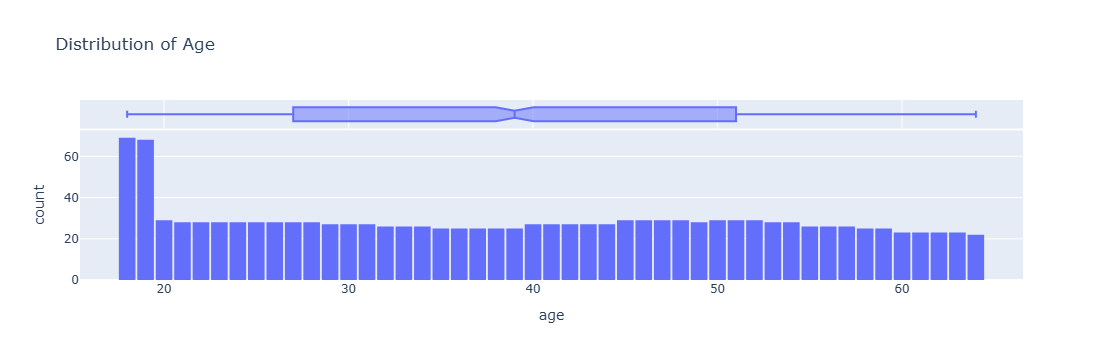

In [15]:
fig = px.histogram(medical_df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

> The distribution of ages in the dataset is almost uniform, with 20-30 customers at every age, except for the ages 18 and 19, which seem to have over twice as many customers as other ages. The uniform distribution might arise from the fact that there isn't a big variation in the number of people of any given age (between 18 & 64) in the USA.

> why there are over twice as many customers with ages 18 and 19, compared to other ages? What are the possible reasons?

> Maybe this insurance company is offering a lower insurance price for people who signup before the age of 20  
> Maybe 18 is the minimum legal age to get the insurance from this company

## Body Mass Index

> Let's look at the distribution of BMI (Body Mass Index) of customers, using a histogram and box plot.

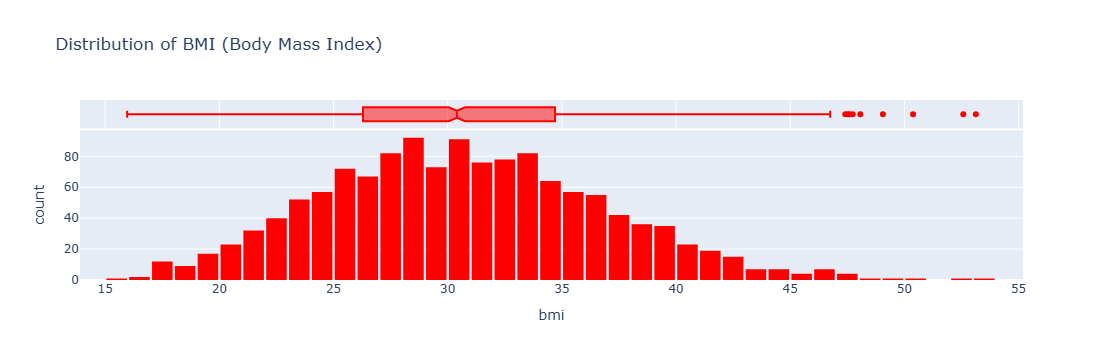

In [16]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

> It seems like bmi is distributed according to Gaussian Distribution(Normal Distribution) centered around the value 30, with a few outliers towards the right

<18.5 = Underweight  
18.5-24.9 = Normal Weight  
25-29.9 = Overweight  
30-39.9 = Obesity  
\>40 = Morbid Obesity

## Charges

> Let's visualize the distribution of "charges" i.e. the annual medical charges for customers. This is the column we're trying to predict. Let's also use the categorical column "smoker" to distinguish the charges for smokers and non-smokers.

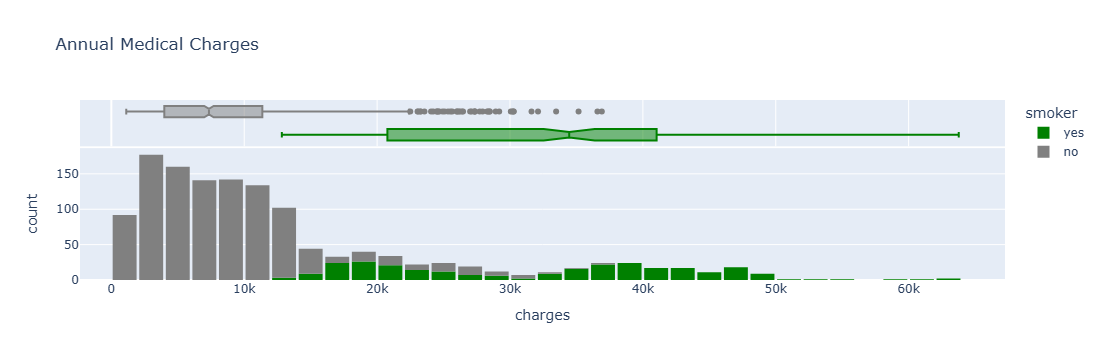

In [17]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

Observations (How charges differ by smoking habit):

1. For most customers, the annual medical charges are under $10,000. Only a small fraction of customer have higher medical expenses, possibly due to accidents, major illnesses and genetic diseases. The distribution follows a "power law" (Exponential Distribution)
2. There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is \\$7300, the median for smokers is close to \\$35,000.

## Smoker

> Let's visualize the distribution of the "smoker" column (containing values "yes" and "no") using a histogram.

In [34]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [35]:
(medical_df.smoker.value_counts(normalize=True) *100).round(2)

smoker
no     79.52
yes    20.48
Name: proportion, dtype: float64

> Only 20% of individuals in the dataset are smokers

In [36]:
medical_df.groupby('sex')['smoker'].value_counts(normalize=True).unstack().T.round(2)

sex,female,male
smoker,,
no,0.83,0.76
yes,0.17,0.24


> These proportions say that majority of both sexes are non smokers  
> Males have a higher likelihood of being smokers

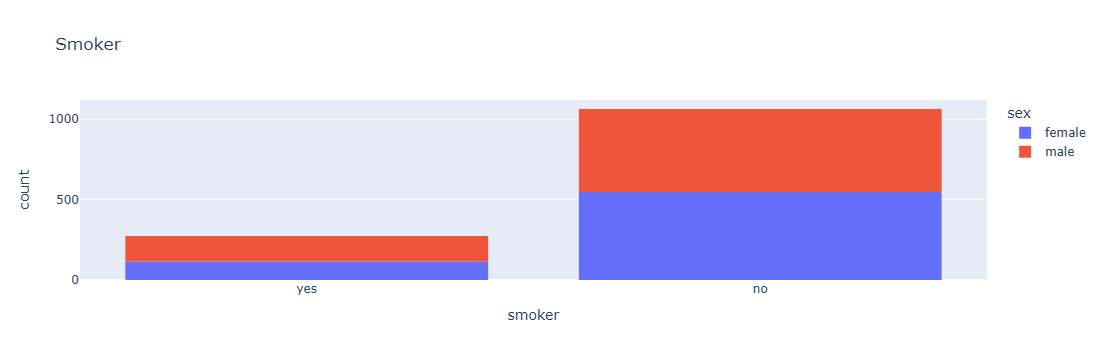

In [37]:
px.histogram(medical_df, x='smoker', color='sex', title='Smoker')

## Age and Charges

> Age would be one of the most important factors when determining the charges

> Each point in the scatter plot represents one customer. We'll also use values in the "smoker" column to color the points.

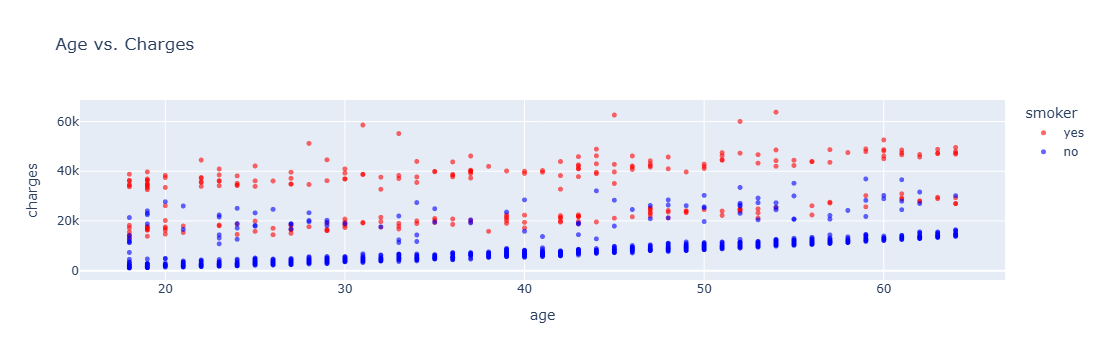

In [38]:
fig = px.scatter(medical_df,
                 x='age',
                 y='charges',
                 color='smoker',
                 color_discrete_sequence=['red', 'blue'],
                 opacity=0.6,
                 hover_data=['sex'],
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

Observations:

* The general trend seems to be that medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.


* We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

     1. The first and the largest cluster consists primary of **presumably** "healthy non-smokers" who have relatively low medical charges compared to others
     
     2. The second cluster contains a mix of smokers and non-smokers. **It's possible** that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".
     
     3. The final cluster consists exclusively of smokers, **presumably** smokers with major medical issues that are possibly related to or worsened by smoking.
     

> Among non somkers, most peopple are having low medical expenses that goes from 0 to 15K.  
> But there are a few non smokers pay high medical expenses and we can assume that is due to accidents, genetic ailments or major illnesses.

> For smokers, the medical expenses are starting from 12K. Here also we can identify 2 separate clusters. The top one can be people who smoke and also have illness or obese or something

## BMI and Charges

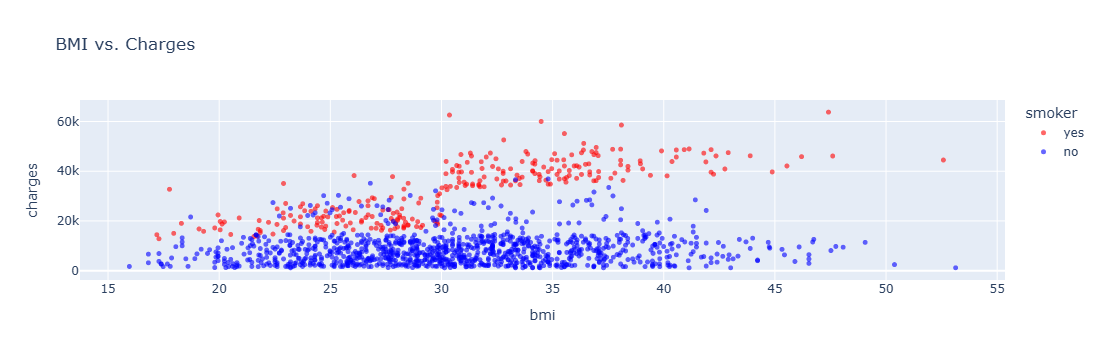

In [39]:
fig = px.scatter(medical_df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 color_discrete_sequence=['red', 'blue'],
                 opacity=0.6,
                 hover_data=['sex'],
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

> It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be significantly higher for smokers with a BMI greater than 30.

## Smokers and Charges

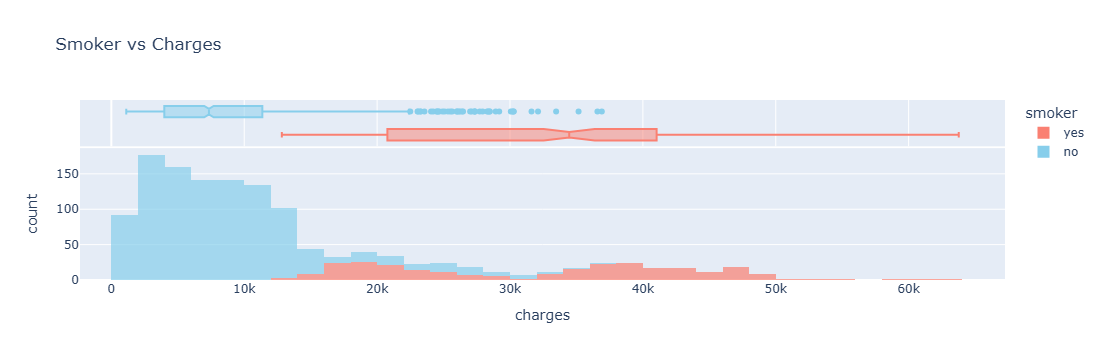

In [40]:
px.histogram(medical_df,
             x='charges',
             color='smoker',
             marginal='box',
             color_discrete_map={'yes':'salmon', 'no':'skyblue'},
             title='Smoker vs Charges',
             opacity=0.7)

Observations:  
Non mokers are charged less than the smokers in overall.  
Expense of non smokers are between 0 to 36 k while the average is around 7K  
Expense of smokers are between 13 to 63 k while the average is around 34K  

## Children and Charges

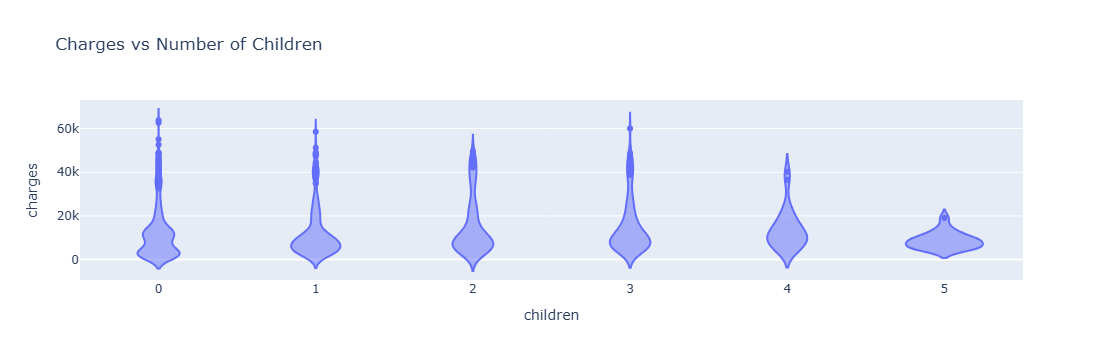

In [41]:
fig = px.violin(medical_df,
                 x='children',
                 y='charges',
                 title='Charges vs Number of Children')
fig.show()

Observations:  
> the number of children is not a primary driver of insurance expenses.  
Costs don't increase with more kids: Having more children does not lead to higher bills; in fact, the highest individual charges (up to $60k+) occur mostly in people with 0, 1, or 3 children.  

> Large families have the lowest peaks: People with 5 children have the most compact distribution, with almost everyone staying below the $20k mark.

## Correlation

Correlation means Strength of a linear relationship between two variables  
Positive Correlation → as X increases, Y tends to increase  
Negative Correlation → as X increases, Y tends to decrease  
If no linear relationship, correlation is 0  

As we can tell from the analysis, the values in some columns are more closely related to the values in "charges" compared to other columns. E.g. "age" and "charges" seem to grow together, whereas "bmi" and "charges" don't.

So the relationship between 2 columns(whether they grow together or not) is often expressed numerically using a measure called the correlation coefficient, which can be computed using the .corr method of a Pandas series.

Correlation coefficient indicate 2 things
* **Strength**: The greater the absolute value of the correlation coefficient, the stronger the relationship.

    * The extreme values of -1 and 1 indicate a perfectly linear relationship where a change in one variable is accompanied by a perfectly consistent change in the other. For these relationships, all of the data points fall on a line. In practice, you won’t see either type of perfect relationship.
    ***(Perfect Positive/ Negative Correlation)***

    * A coefficient of zero represents no linear relationship. As one variable increases, there is no tendency in the other variable to either increase or decrease.***(No Correlation)***
    
    * When the value is in-between 0 and +1/-1, there is a relationship, but the points don’t all fall on a line. As r approaches -1 or 1, the strength of the relationship increases and the data points tend to fall closer to a line.***(Strong/ Weak Postivie/ Negative Correlation)***


* **Direction**: The sign of the correlation coefficient represents the direction of the relationship.

    * Positive coefficients indicate that when the value of one variable increases, the value of the other variable also tends to increase. Positive relationships produce an upward slope on a scatterplot.
    
    * Negative coefficients represent cases when the value of one variable increases, the value of the other variable tends to decrease. Negative relationships produce a downward slope.

      <img src="https://i.imgur.com/3XUpDlw.png" width="360">

The correlation coefficient has the following formula:

   <img src="https://i.imgur.com/unapugP.png" width="360">

>

In [47]:
# To compute the correlation between charges and age
print(medical_df.charges.corr(medical_df.age))

0.2990081933306476


In [48]:
# To compute the correlation between charges and bmi
print(medical_df.charges.corr(medical_df.bmi))

0.19834096883362895


In [57]:
# To compute the correlation between charges and children
print(medical_df.charges.corr(medical_df.children))

0.06799822684790487


> So it seems like the corelatino of age is greater than bmi and children

In [58]:
# To compute the correlation for categorical columns, they must be converted into numeric columns first
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
print(medical_df.charges.corr(smoker_numeric))

0.7872514304984772


> So this is probably the highest correlation

In [61]:
# To compute the correlation coefficients between all pairs of numeric columns
medical_df.select_dtypes(include='number').corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


This correlation matrix and is often visualized using a heatmap.

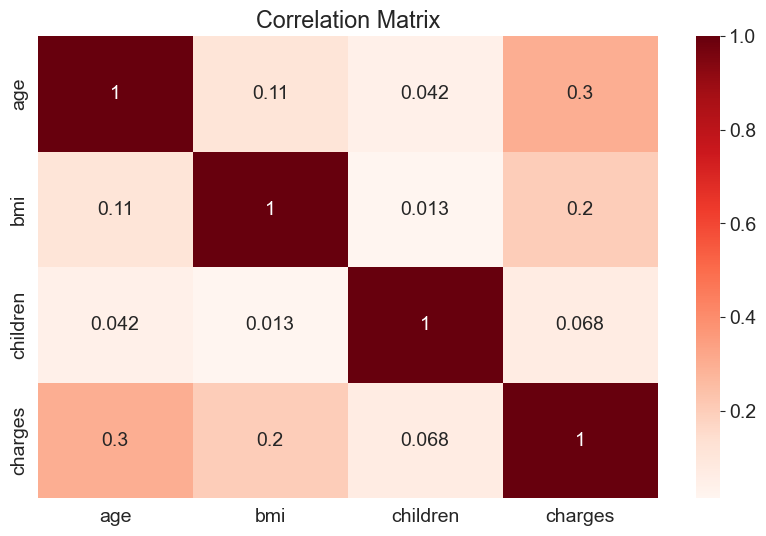

In [62]:
sns.heatmap(medical_df.select_dtypes(include='number').corr(), cmap='Reds', annot=True)
plt.title('Correlation Matrix');
plt.show();

#### **Corelation vs Causation fallacy**

> Ice cream sales vs drowning incidents → highly correlated in summer  
> ❌ Conclusion: Ice cream causes drowning?  
>✅ Reality: Temperature (summer) is the hidden variable

>age correlated with charges → good predictor  
>But we cannot say high age directly increases charges

> So, just because two variables are correlated (move together) does NOT mean that one causes the other. (High correlation ≠ causation)

Note:

1. High correlation ≠ causation  
   * Just because two things move together doesn’t mean one causes the other.

2. Three reasons two variables X and Y can be correlated  
   * X causes Y → e.g., smoking → higher charges
   * Y causes X → e.g., unlikely here, but in general this is possible
   * Both caused by a third factor Z → e.g., ice cream sales and drowning both increase in summer (summer = Z)

3. Correlation can also be misleading
   * Small sample sizes may make unrelated variables look correlated

4. Why this matters in ML
   * Computers only see patterns (correlations)
   * They cannot know causation
   * If we blindly trust a model, decisions may have serious consequences in real life (like insurance premiums, medical decisions, or loans)

5. Solution
   * Humans must investigate why the model made a prediction
   * Determine if the relationships make sense in the real world (causally), not just statistically


   > **“Just because two things are correlated doesn’t mean one causes the other. Correlation can happen for many reasons, including a hidden third factor or random chance. Computers only see correlation, so we need humans to check whether a prediction makes sense in the real world.”**

# **03. Linear Regression using a Single Feature**

* We now know that the "smoker" and "age" columns have the strongest correlation with "charges".   
* We cant really use somker, bcs it's just a Yes, No value. So, Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. First, let's create a data frame containing just the data for non-smokers.



In [64]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

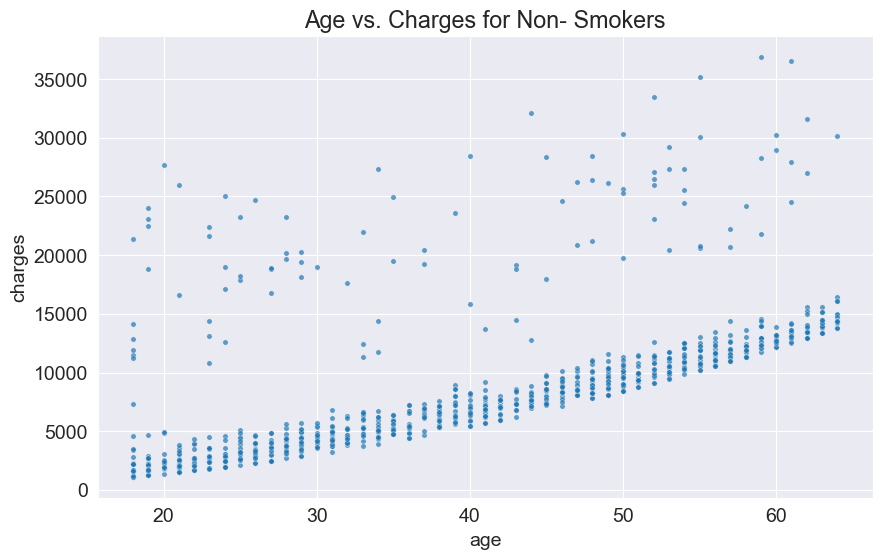

In [65]:
# Lets use seaborn cuz don't need any interactivity here
plt.title('Age vs. Charges for Non- Smokers')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15);
plt.show()

Apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. A line on the X&Y coordinates has the following formula:

$y = wx + b$

The line is characterized two numbers: $w$ (called "slope") and $b$ (called "intercept").

### Model

In the above case, the x axis shows "age" and the y axis shows "charges". Thus, we're assume the following relationship between the two:

$charges = w \times age + b$

We'll try determine $w$ and $b$ for the line that best fits the data.

* This technique is called _linear regression_, and we call the above equation a _linear regression model_, because it models the relationship between "age" and "charges" as a straight line.

* The numbers $w$ and $b$ are called the `parameters` or `weights` of the model.

* The values in the "age" column of the dataset are called the _inputs_ to the model and the values in the charges column are called "targets".

Let define a helper function `estimate_charges`, to compute $charges$, given $age$, $w$ and $b$.


In [66]:
def estimate_charges(age, w, b):
  return w * age + b

The `estimate_charges` function is our very first _model_.

Let's _guess_ the values for $w$ and $b$ and use them to estimate the value for charges.

In [67]:
w = 50
b = 100

In [68]:
estimate_charges(30, w, b)

1600

In [69]:
ages = non_smoker_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [70]:
estimated_charges = estimate_charges(ages, w, b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [71]:
# Compare above estimated charges with the actual charges
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

So what we can see is our estimated values are very low than the actual values

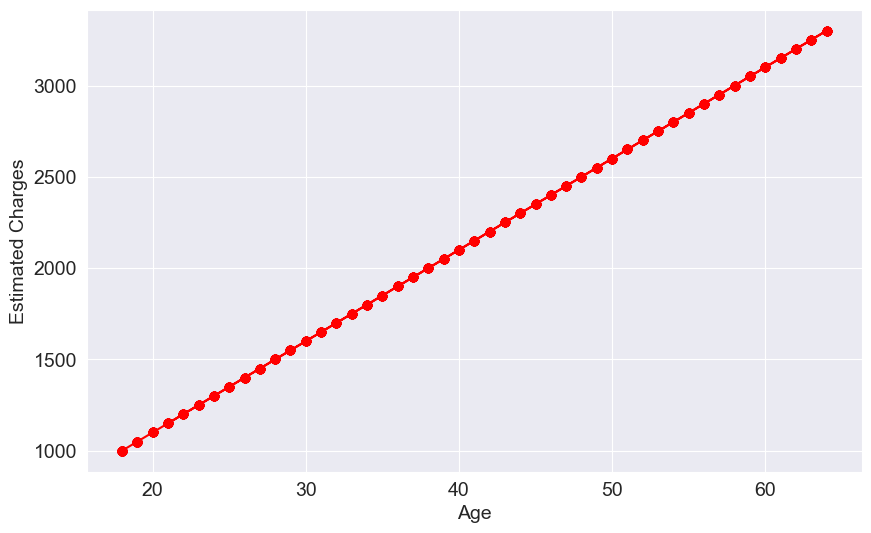

In [72]:
# We can plot the estimated charges using a line graph.
plt.plot(ages, estimated_charges, 'r-o');
plt.xlabel('Age');
plt.ylabel('Estimated Charges');
plt.show();

So now we have a model. we give the model some data(ages) and it gives us an output. But we wanna know how good our model is. To that, we can plot this above line, on top of the scatter plot of the actual data

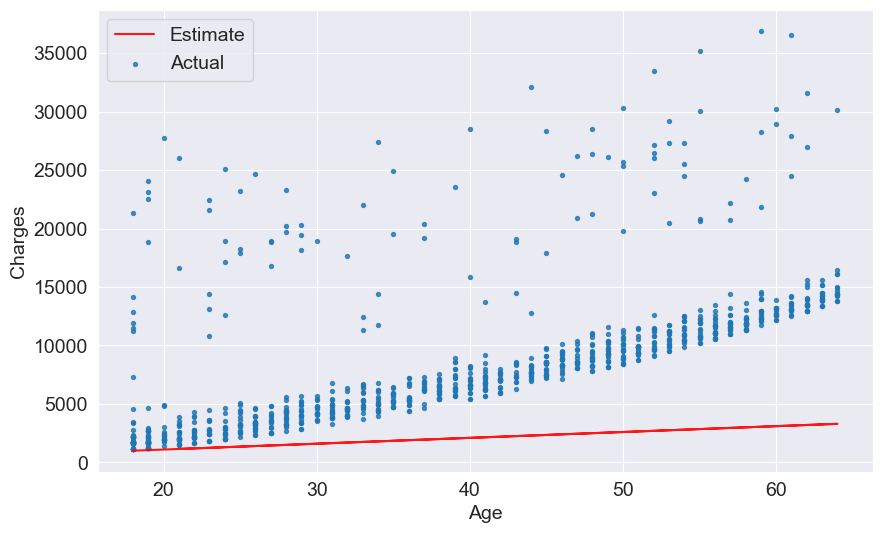

In [73]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha=0.9);
plt.scatter(ages, target, s=8,alpha=0.8);
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);
plt.show();

Clearly, the our estimates are quite poor and the line does not "fit" the data. However, we can try different values of $w$ and $b$ to move the line around. Let's define a helper function `try_parameters` which takes `w` and `b` as inputs and creates the above plot.

In [74]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);
    plt.show();

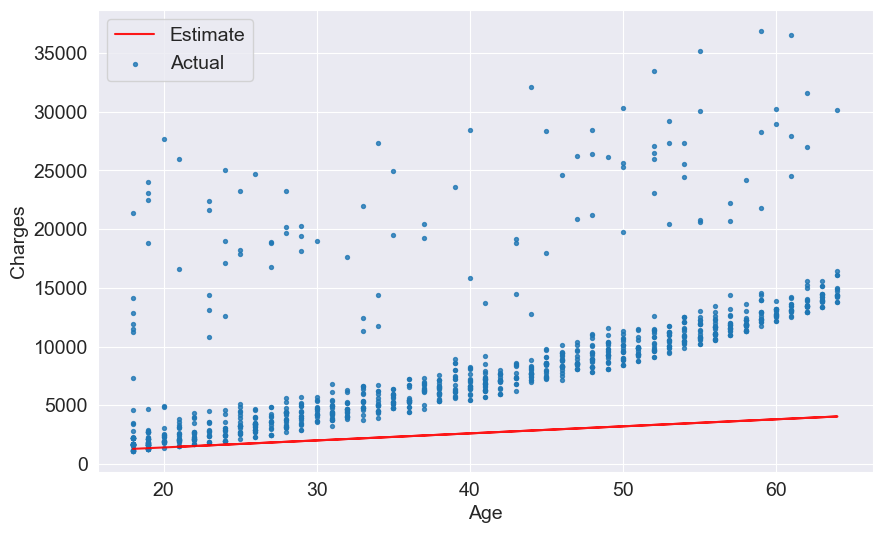

In [75]:
try_parameters(60, 200)

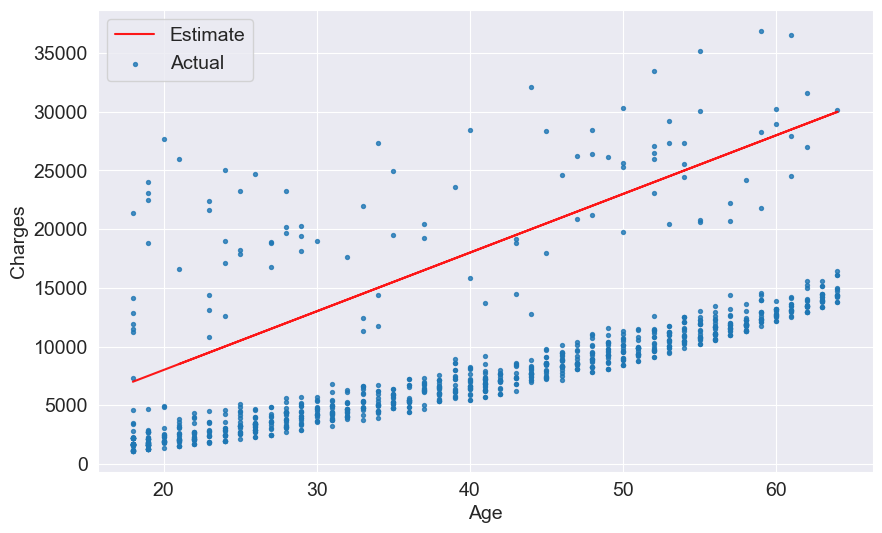

In [76]:
try_parameters(500, -2000)

As we change the values, of $w$ and $b$ manually, trying to move the line visually closer to the points, we are _learning_ the approximate relationship between "age" and "charges".

Wouldn't it be nice if a computer could try several different values of `w` and `b` and _learn_ the relationship between "age" and "charges"? To do this, we need to solve a couple of problems:

1. We need a way to measure numerically how well the line fits the points.

2. Once the "measure of fit" has been computed, we need a way to modify `w` and `b` to improve the fit.

If we can solve the above problems, it should be possible for a computer to determine `w` and `b` for the best fit line, starting from a random guess.

> 1. We have eyes. we can see where the line is. But computer can not see. **So we need a way to measure numerically how well the line fits to the points**

> 2. We are able to guess which way we should move w and b by loking at how far the line is from the points. **So after measuring, we need a way to modify w and b to improve the fit**

> If we solve these 2 problems, computer can determine w and bfor the best fit line starting from a random guess

> ***So let's solve the first problem***

### Loss/Cost Function

We can compare our model's predictions with the actual targets using the following method:

* Calculate the difference between the targets and predictions (the differenced is called the "residual")
* Square all elements of the difference matrix to remove negative values.
* Calculate the average of the elements in the resulting matrix.
* Take the square root of the result

The result is a single number, known as the **root mean squared error** (RMSE). The above description can be stated mathematically as follows:

<img src="https://i.imgur.com/WCanPkA.png" width="360">

Geometrically, the residuals can be visualized as follows:

<img src="https://i.imgur.com/ll3NL80.png" width="420">


Let's define a function to compute the RMSE.

In [77]:
!pip install numpy --quiet

In [78]:
import numpy as np

In [79]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

Lets compute the RMSE for our model with a sample set of weights

In [82]:
w = 50
b = 100

In [83]:
predicted = estimate_charges(non_smoker_df.age, w,b)

In [84]:
# actual charges
targets = non_smoker_df.charges

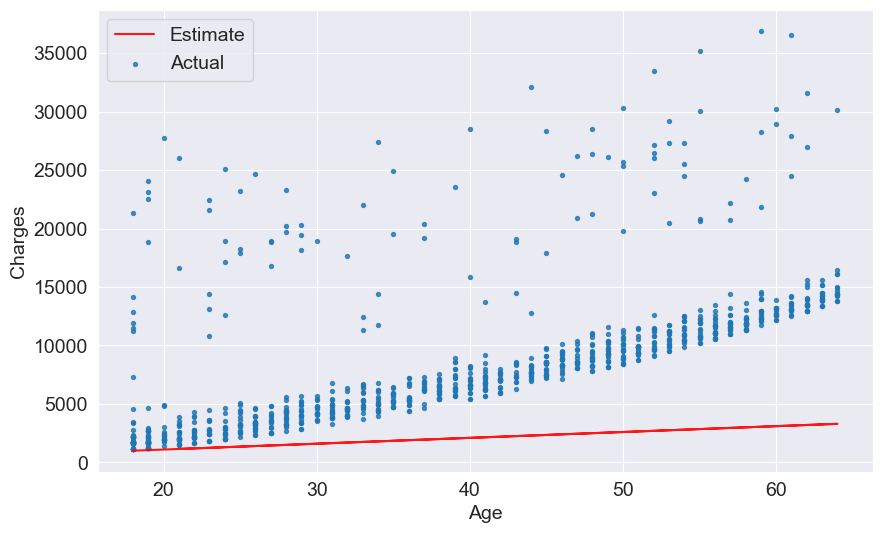

In [85]:
try_parameters(w,b)

In [86]:
# Calculate the Root Mean Squared Error between the targets and predicted points
print(rmse(targets, predicted))

8461.949562575493


Here's how we can interpret the above number: *On average, each element in the prediction differs from the actual target by \\$8461*. The higher the rmse value, worst the model is

The result(rmse) is also called as the **loss** because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model.

Let's modify the `try_parameters` functions to also display the loss.

> Before we train the computer to figure out the lowest losslets try and do it manually

In [87]:
# Let's modify the `try_parameters` functions to also display the loss.
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print('RMSE Loss: ', loss)
    plt.show();


> Now try different parameters for w and b and try to get a low RMSE Loss

RMSE Loss:  4701.206270955806


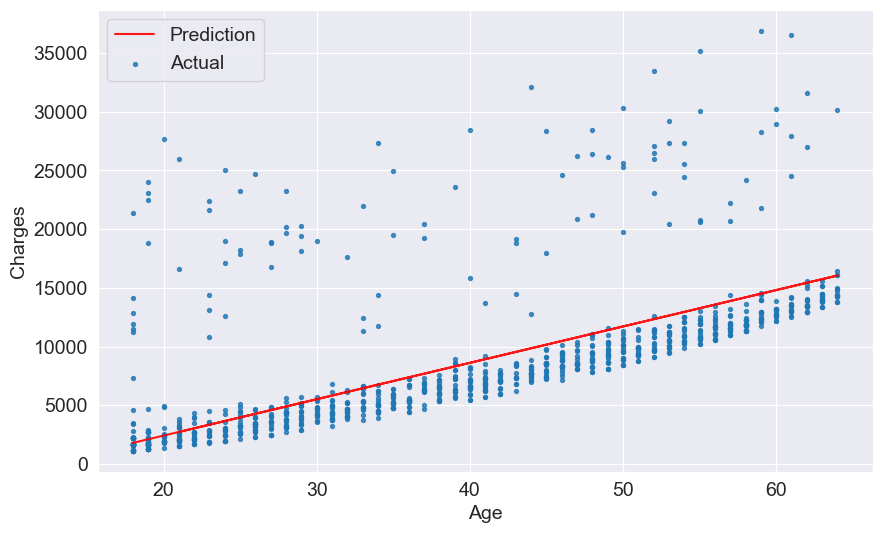

In [88]:
try_parameters(310,-3790)

> ***Now let's solve the second problem***

## **Optimizer**

### Optimizer

Now we can find the rmse/loss to a given parametes/weights(`w` and `b). So now what we have to do is, we have to reduce loss to improve the line

Next, we need a strategy to modify weights `w` and `b` to reduce the loss and improve the "fit" of the line to the data. For this we can use 2 methods.

* Ordinary Least Squares (better for smaller datasets)
* Stochastic gradient descent (better for larger datasets)

In general we don look at these strategies in detail bcs we'll never have to implement these. It helps to understand but we'll mostly use libraries.

Both of these have the same objective: to minimize the loss, however, while ordinary least squares directly computes the best values for `w` and `b` using matrix operations, while gradient descent uses a iterative approach, starting with a random values of `w` and `b` and slowly improving them using derivatives.

Here's a visualization of how gradient descent works:

![](https://miro.medium.com/max/1728/1*NO-YvpHHadk5lLxtg4Gfrw.gif)




# **Linear Regression Using Scikit-learn**

In practice, we'll never need to implement either of the above methods yourself. You can use a library like `scikit-learn` to do this for you. This library contains functions, modules for ML with Python. It is the most used library for ML

In [89]:
!pip install scikit-learn --quiet

Let's use the `LinearRegression` class from `scikit-learn` to find the best fit line for "age" vs. "charges" using the ordinary least squares optimization technique.

In [90]:
from sklearn.linear_model import LinearRegression

In [91]:
# First we create a new model object.
# With this we say to scikit learn that we want to assume a linear relationship between our inputs and targets
model = LinearRegression()

Every model in scikit-learn has a fit() method. This method takes some parameters and targets and it fits a line between those parameters and targets

In [92]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



Now that the input `X` must be a 2-d array, so we'll need to pass a dataframe, instead of a single column.  
`inputs` has to be a dataframe  
`targets` can be an array

In [94]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape :', inputs.shape)
print('targes.shape :', targets.shape)

inputs.shape : (1064, 1)
targes.shape : (1064,)


WHY [['age']] and NOT ['age']

* when we call model.fit(X, y)  
-X must ALWAYS be 2D -(Even if we have only one feature, scikit-learn still wants it as 2D (a column matrix), not 1D)  
-y is usually 1D  


* Why y is usually 1D?  
y is the target/output values - what you want the model to predict.  
Usually each sample has one target value, so it’s just a list → 1D.  
If you have multiple outputs per sample, y can be 2D

In [95]:
 # Next, we can use the `fit` method of the model to find the best fit line for the inputs and targets.
model.fit(inputs, targets)

LinearRegression()

> Here we are telling scikit-learn, here are some inputs **(ages)** for you and some targets **(charges)** for those inputs. And asking to calculate the loss by first getting some random `w` and `b` and get the predictions. Compare the predictions with the targets. See how bad your predictions are. And then use a gradient descent algorithm or other optimization stratergy to improve you values of `w` and `b` and keep improving till you can not improve anymore. And then give me the final result. So that's what happen when we call model.fit()

> After running the model.fit() now we can make predictions using the model. Lets try predicting the charges for the ages 23, 37, 61

> But in .predict() also it requires a 2D array(a table)  
eg: -   
model.predict([[23]])  
model.predict([[23],[37],[61]])

In [96]:
model.predict(np.array([[23],[37],[61]]))

C:\Users\ahame\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

> According to above predicted charges, it seems like the model has done a pretty good job

> Now let's compute the predictions for the entire set of inputs(All the ages)

In [97]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [84]:
# actual charges
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


> So far the predictions are good and only have slight errors around a thousand

> Let's compute the RMSE loss to evaluate the model

In [85]:
print(rmse(targets, predictions))

4662.505766636395


Seems like our prediction is off by `$4000` on average, which is not too bad considering the fact that there are several outliers. This means our average Error is `$4662`. But actually when we look at the values we saw that we are off by much less(around $1000). It says 4000 here bcs some of outliers

> So this is the whole process of ML. We assume a certain relationship between inputs and targets, which is the linear relationship. We then find a way to measure how bad our model is performing, based on random parameters that we picked initially. And then we use some optimization algorithms to improve the parameters of the model(in this cas `w` and `b`) till we can minimize the loss.

In [86]:
# w
model.coef_

array([267.24891283])

In [87]:
# b
model.intercept_

np.float64(-2091.4205565650864)

Are these parameters close to your best guesses? LOL nope, I tried though

> Now let's visualize the line created by the above parameters

RMSE Loss:  4662.505766636395


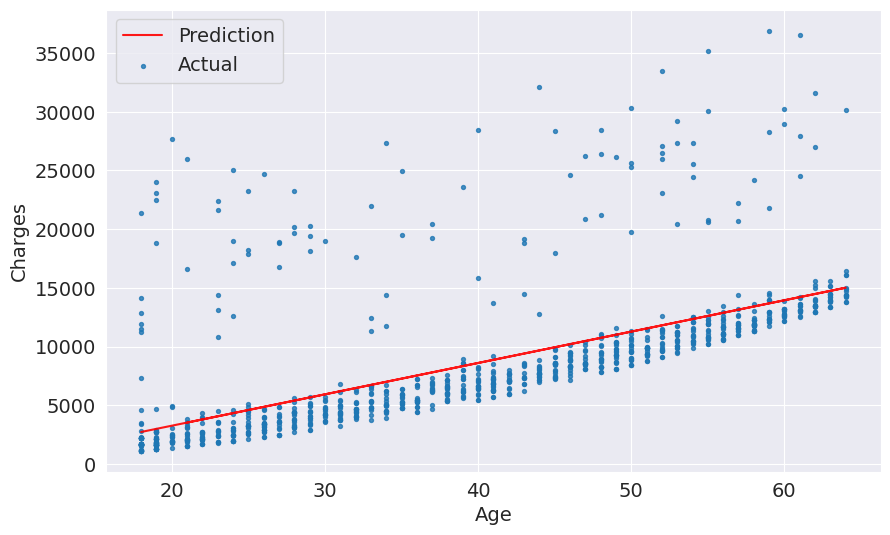

In [88]:
try_parameters(model.coef_, model.intercept_)

> Indeed the line is quite close to the points. It is slightly above the cluster of points, because it's also trying to account for the outliers

* In same way we can train a linear regression model to estimate medical charges for smokers

### Machine Learning

We've just trained our first _machine learning model!_ Machine learning is simply the process of computing the best parameters to model the relationship between some feature and targets.

Every machine learning problem has three components:

1. **Model**

2. **Cost Function**

3. **Optimizer**

We'll look at several examples of each of the above in future tutorials. Here's how the relationship between these three components can be visualized:

<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">

* We put some Input data into the model and get some Output. We get both the target and predicted output into the Error / Loss Function. Then we apply an optimization method. And that optimization method changes changes parameters (`w` and `b`) of the model. So model gets slightly better(model improved). Then we again put some Input data and get Output and this repeats.

* This is the animation we saw above

> As we've seen above, it takes just a few lines of code to train a machine learning model using `scikit-learn`.

In [89]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age']], non_smoker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Now we can get the predictions with any data. Since we dont have new data lets get the predictions for same data and see

# Generate predictions
predictions = model.predict(inputs)

# Whenever we calculate the predictions, it's always a good idea to compare the targets with predictions if we have the actual targets
# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.505766636395


# **04. Linear Regression using Multiple Features**

So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

$charges = w_1 \times age + w_2 \times bmi + b$
  
With one feature:  
$charges = w \times age + b$


We need to change just one line of code to include the BMI.

In [90]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Now we can get the predictions with any data. Since we dont have new data lets get the predictions for same data and see

# Generate predictions
predictions = model.predict(inputs)

# Whenever we calculate the predictions, it's always a good idea to compare the targets with predictions if we have the actual targets
# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


- So now we go from the loss of 4662.505 to 4662.312  

- So clearly `bmi` didnot make a major impact. Why is that? Because bmi has a very weak correlation with charges, especially for non smokers

In [91]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

In [93]:
# We can even see that in this scatter plot. Theres no line we can see here
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

- So, that's why we can not see any improvement in the loss

Let's also check the parameters of the model.

In [94]:
model.coef_, model.intercept_
# coefficient of age, coefficient of bmi, intercept
#coefficient of age and intercept has changed only slightly. And the coefficient of bmi is a very little amount

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

Clearly, BMI has a much lower weightage, and you can see why. It has a tiny contribution, and even that is probably accidental. This is an important thing to keep in mind: you can't find a relationship that doesn't exist, no matter what machine learning technique or optimization algorithm you apply.

So, if company ask us to train a model using bmi of people, we should say bmi doesnot have any relationship with charges

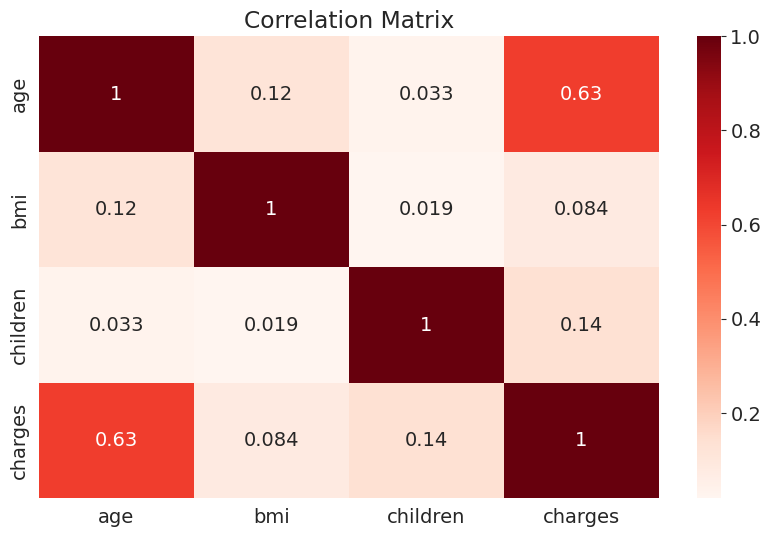

In [97]:
sns.heatmap(non_smoker_df.select_dtypes(include='number').corr(), cmap='Reds', annot=True)
plt.title('Correlation Matrix');
plt.show();

Let's go one step further, and add the third numeric column: "children", which seems to have some correlation with "charges".

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + b$

In [95]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [96]:
# Lets create a strip plot
fig = px.strip(non_smoker_df, x='children', y='charges', title= "Children vs. Charges")
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

the lower value is getting increased with no. of children. we can see a somewhat increasing trend. And that's why we have a slightly positive correlation

In [98]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038247


Once again, we don't see a big reduction in the loss(only around $60), even though it's greater than in the case of BMI.

> **EXERCISE**: Repeat the steps is this section to train a linear regression model to estimate medical charges for all customers(Not dividing as smokers or non-smokers). Visualize the targets and predictions, and compute the loss. Is the loss lower or higher?

In [99]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


since now we have data of smokers also the data is spreaded more widelya and it is hard to fit than before. So obviously our loss is going to be very high. So our model is completely useless at this point bcs of the charge if off by $11000

# **05. Using Categorical Features for Machine Learning**

So the next thing that we might wanna do is to start using the categorical features for ML as well. So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset.

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this:

1. If a categorical column has just two categories (it's called a binary category), then we can replace their values with 0 and 1. (Eg:- Smoker or not)
2. If a categorical column has more than 2 categories, we can perform one-hot encoding i.e. create a new column for each category with 1s and 0s. (Eg:- Region)
3. If the categories have a natural order (e.g. cold, neutral, warm, hot), then they can be converted to numbers (e.g. 1, 2, 3, 4) preserving the order. These are called ordinals  

- We'll often have to decide with option 2 and 3. Wether we have to convert certain categories into numbers or one-hot
- When we see ther is a high correlation between these categories in their natural order and target, then we should convert it into numbers
- If we do not see a correlation we can convert them into one-hot

## i. Binary Categories

The "smoker" category has just two values "yes" and "no". Let's create a new column "smoker_code" containing 0 for "no" and 1 for "yes".  
A weight(penalty) would applied when we have a smoker


/tmp/ipython-input-1041402944.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




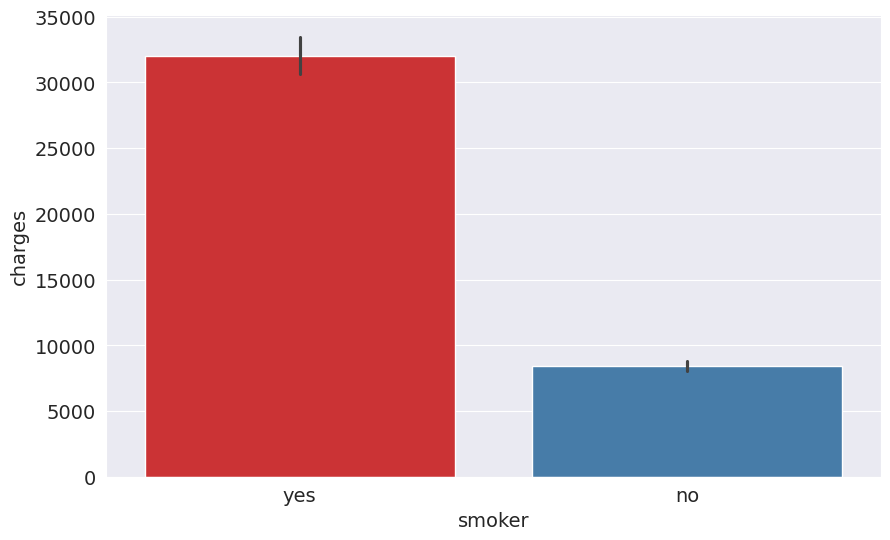

In [121]:
sns.barplot(data=medical_df, x='smoker', y='charges', palette='Set1');

In [101]:
# Create a new column called 'smoker_codes'
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [102]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [103]:
# Check correlation
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

We can now use the `smoker_code` column for linear regression.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + b$

In [104]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.439217188081


The loss reduces from `11355` to `6056`, almost by 50%! This is an important lesson: never ignore categorical data.


Let's try adding the "sex" column as well.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + b$

/tmp/ipython-input-873919372.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='sex', ylabel='charges'>

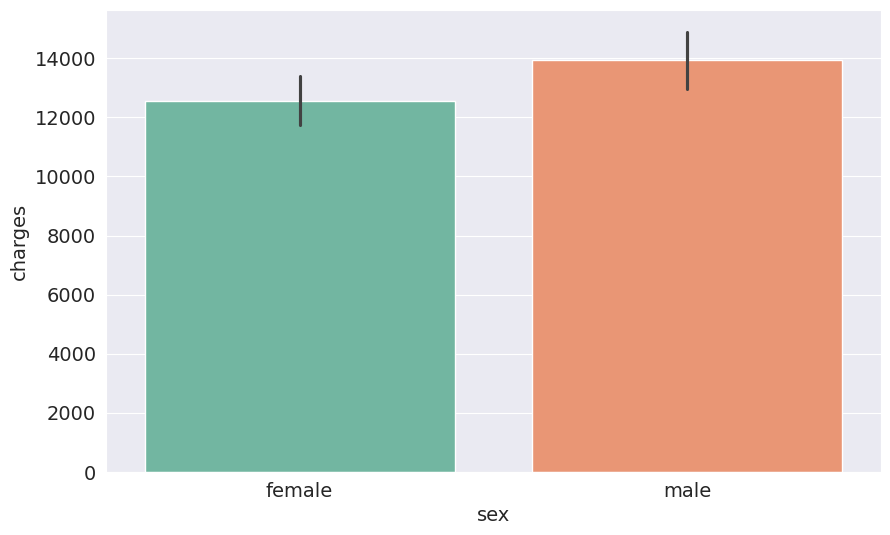

In [119]:
sns.barplot(data=medical_df, x='sex', y='charges', palette='Set2')

In [106]:
sex_codes = {'female': 0, 'male': 1}

In [107]:
medical_df['sex_code'] = medical_df.sex.map(sex_codes)

In [108]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [109]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.100708754546


As you might expect, this does have a significant impact on the loss. we can maybe even ignore the 'sex' column

## ii. One-hot Encoding

The "region" column contains 4 values, so we'll need to use hot encoding and create a new column for each region.

![](https://i.imgur.com/n8GuiOO.png)



/tmp/ipython-input-4221186854.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




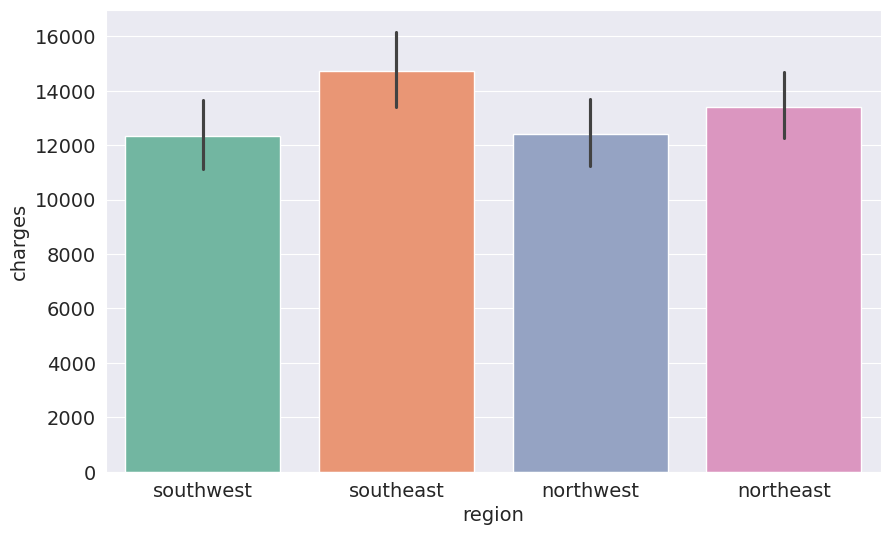

In [113]:
sns.barplot(data=medical_df, x='region', y='charges', palette='Set2');

We can see that there is a difference by region. Maybe region is a factor

In [114]:
#  We use OneHotEncoder class to one-hot encode the data
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [115]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [116]:
# create 4 columns in medical_df and give the data one_hot
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot

In [117]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


Let's include the region columns into our linear regression model.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [118]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


Once again this leads to a fairly samll reduction in the loss

> We can already see that lot of these other factors are not really helping. It seems like `age` and `smoker` are the 2 biggest factors, and the rest of them don't really matter. They maybe give us like a 1% difference, but not so much

> **EXERCISE**: Are two separate linear regression models, one for smokers and one of non-smokers, better than a single linear regression model? Why or why not? Try it out and see if you can justify your answer with data.

Try creating 2 separate linear regression models and use all other parameters with normal weights, just exclude `smoker` and create 2 separate models. One for smokers and other for non-smokers. And see if the losses for each models are lower than one we created now. If so, that means it is better to create 2 models rather than using one Linear Regression model. And that's a decision we'll have to make as a Data Scientist.  

For example, `bmi` does not make a big difference for non-smokers, but for smokers. So right now we have added a weight for `bmi` but ideally the weight applied to `bmi` should really depend on whether the person is a smoker or not. So all these factors have to be taken into consideration. So sometimes 2 linear regression models maybe better than one

# **06. Model Improvements**

Let's discuss and apply some more improvements to our model.

### Feature Scaling

Recall that due to regulatory requirements, we also need to explain the rationale behind the predictions our model.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

To compare the importance of each feature in the model, our first instinct might be to compare their weights.

In [139]:
medical_df[input_cols].loc[10]

,10
age,25.00
bmi,26.22
children,0.00
smoker_code,0.00
sex_code,1.00
northeast,1.00
northwest,0.00
southeast,0.00
southwest,0.00


Let's say a new person comes to get insurance with these details

In [140]:
model.predict([[28, 30, 2, 1, 0, 0, 1, 0, 0.]])

array([196735.05510156])

- So our model predicts that estimated medical charges are $29875.81463599. We also look at the other factors, but this model's prediction is one of the major factors we look up to.
- So now this person asks why we predicted that amount for him. We can't hide behind our model and just say that our model says so, that's why we are charging that. We should be able to explain why our model gives a certain output
- Fortunately, in the case of linear regression that is fairly straightforward. Model applies weights to each input. We can say we are charging because you have a certain bmi, and bmi has a certain weight in our model. We can check the coefficients of our model. These are the weights applied to the model.

In [141]:
model.coef_

array([ 3607.47273619,  2067.69196584,   572.99820995, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

- We can say we have accounted $23848.53454191 for simply because you are a smoker. And that could be fine in certain cases because smoker is a simple 0 or 1 column and it makes sense.
- But if we look at weights carefully, (lets put them into a dataframe)

In [142]:
weights_df = pd.DataFrame({
    'feature': np.append(input_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df

,feature,weight
0,age,3607.472736
1,bmi,2067.691966
2,children,572.998210
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,8466.483215


- It seems like `bmi` has a higher weight than `age` and `children` has even more higher weight. So this goes completely opposite to what we understood in earlier stages. We found that `age` is the one of the most important factors. And we saw that for non-smokers, `bmi` has no bearing. And `children` also had no bearing. So whats going on here??? Our model's results seem to be completely out of sync with the weights that it is assigning to the different features. We understood earlier that `age` has a far more important impact than `bmi` , `children` , `sex-code` etc. So what's really going on here???

- What's going on is that the range of values for `bmi` is limited. (15 to 40). `notheast` column is only going to take the values 0 or 1. That means the maximum change that the `northeast` column can compute and create in the final output is around 500. On the other hand `age` can go up to 60. so it can create an amount of $256 * 60 in the final output. So the weights do not accurately represents which features are important because the ranges are different for each feature. That's one issue.
- Another issue that happens is, (not so much in linear regression but in later classes) when one column has a very large range of inputs(like age has from 15 to 60), and one column has a very low range of inputs(like region can only go from 0 to 1) so then when we are calculating the loss and when we are performing any optimizations, that large number disproportionately affects the optimization process because ultimately our model is looking at a single number(the loss). Loss is computed using all of these inputs and outputs and weights and everything. And if some column has a very large inputs, then it will disproportionately contribute to the loss. So most of our efforts will be spent just optimizing for that one single column. So that's where we perform a certain thing called **Standardization**.
- After applying standardization, the values become centered around zero. And they are also scaled down so that it becomes a normal distribution with standard deviation of 1 and mean of 0. So we scale down all the values to small numbers in the range of 1 to -1 or 2 to -2 likewise. And there mean is 0. So we do this standardization process to every numeric column(categorical columns are already between 0 and 1). Then the weights will make lot more sense. Here's how we do it,

Tutor:  
While it seems like BMI and the "northeast" have a higher weight than age, keep in mind that the range of values for BMI is limited (15 to 40) and the "northeast" column only takes the values 0 and 1.

Because different columns have different ranges, we run into two issues:

1. We can't compare the weights of different column to identify which features are important
2. A column with a larger range of inputs may disproportionately affect the loss and dominate the optimization process.

For this reason, it's common practice to scale (or standardize) the values in numeric column by subtracting the mean and dividing by the standard deviation.

![](https://i.imgur.com/dT5fLFI.png)

We can apply scaling using the StandardScaler class from `scikit-learn`.

In [143]:
from sklearn.preprocessing import StandardScaler

In [144]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

All it does is it computes the mean and the variance for each numeric columns

In [145]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [146]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

Now we can scale the data

In [147]:
# this is the data that we wanna transform
medical_df[numeric_cols]

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0
...,...,...,...
1333,50,30.970,3
1334,18,31.920,0
1335,18,36.850,0
1336,21,25.800,0


In [148]:
# Once we transform, this is what the valaues will become. Values will go between -1 and 1
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

These can now be combined with the categorical data

In [149]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values

Now we train the model

In [150]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = medical_df.charges

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


So we got the same loss. Scaling have not much affected to the loss **(In Linear Regression the scaling does not affect the loss)**. But the difference now is that when we look at the weight for every feature,

We can now compare the weights in the formula:

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [152]:
# Now weight for every feature makes lot more sense
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


1 represents the intercept

So as in above table, we can see that we have different levels of weight. And now we can tell the person that in our model smoking has a very high weight of 23000 dollars

> Now when a new person comes to us, we will have to scale the values before putting them into model. See below example

In [ ]:
new_customer = [[28, 30, 2, 1, 0, 0, 1, 0, 0.]]

In [153]:
scaler.transform([[28, 30, 2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



array([[-0.79795355, -0.10882659,  0.75107928]])

In [154]:
model.predict([[-0.79795355, -0.10882659,  0.75107928, 1, 0, 0, 1, 0, 0.]])

array([29875.81463371])

### How to Approach a Machine Learning Problem

Here's a strategy you can apply to approach any machine learning problem:

1. Explore the data and find correlations between inputs and targets
2. Pick the right model, loss functions and optimizer for the problem at hand
3. Scale numeric variables and one-hot encode categorical data
4. Set aside a test set (using a fraction of the training set)
5. Train the model
6. Make predictions on the test set and compute the loss

We'll apply this process to several problems in future tutorials..